In [163]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split


In [164]:
import time
before = time.time()

In [165]:
data_path = "/content/green_tripdata_2026-05.parquet"

In [166]:
df = pd.read_parquet(data_path)

In [167]:
df

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,cbd_congestion_fee
0,2,2026-05-01 00:02:02,2026-05-01 00:21:03,N,1.0,198,56,1.0,4.08,21.90,...,0.5,0.00,0.00,NaN,1.0,24.40,2.0,1.0,0.00,0.0
1,2,2026-05-01 00:30:22,2026-05-01 00:53:51,N,1.0,66,262,1.0,8.07,35.90,...,0.5,1.80,0.00,NaN,1.0,42.95,1.0,1.0,2.75,0.0
2,2,2026-05-01 00:30:17,2026-05-01 00:50:34,N,1.0,66,112,1.0,5.97,27.50,...,0.5,1.00,0.00,NaN,1.0,31.00,1.0,1.0,0.00,0.0
3,2,2026-05-01 00:05:49,2026-05-01 00:06:03,N,5.0,53,53,1.0,0.00,22.00,...,0.0,4.60,0.00,NaN,1.0,27.60,1.0,2.0,0.00,0.0
4,2,2026-05-01 00:45:47,2026-05-01 00:53:20,N,5.0,200,265,0.0,1.86,13.11,...,0.0,0.00,0.00,NaN,1.0,14.11,1.0,2.0,0.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44916,2,2026-05-31 21:06:04,2026-05-31 21:18:11,None,NaN,166,239,NaN,2.31,16.87,...,0.5,2.00,0.00,NaN,1.0,23.12,NaN,NaN,NaN,0.0
44917,2,2026-05-31 21:20:00,2026-05-31 21:49:00,None,NaN,25,222,NaN,6.79,39.15,...,0.5,0.00,0.00,NaN,1.0,40.65,NaN,NaN,NaN,0.0
44918,2,2026-05-31 22:11:20,2026-05-31 22:36:44,None,NaN,129,36,NaN,6.38,26.52,...,0.5,6.59,0.00,NaN,1.0,34.61,NaN,NaN,NaN,0.0
44919,2,2026-05-31 23:08:05,2026-05-31 23:36:49,None,NaN,82,75,NaN,8.76,33.98,...,0.5,0.00,7.46,NaN,1.0,42.94,NaN,NaN,NaN,0.0


In [168]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44921 entries, 0 to 44920
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               44921 non-null  int32         
 1   lpep_pickup_datetime   44921 non-null  datetime64[us]
 2   lpep_dropoff_datetime  44921 non-null  datetime64[us]
 3   store_and_fwd_flag     39149 non-null  object        
 4   RatecodeID             39149 non-null  float64       
 5   PULocationID           44921 non-null  int32         
 6   DOLocationID           44921 non-null  int32         
 7   passenger_count        39149 non-null  float64       
 8   trip_distance          44921 non-null  float64       
 9   fare_amount            44921 non-null  float64       
 10  extra                  44921 non-null  float64       
 11  mta_tax                44921 non-null  float64       
 12  tip_amount             44921 non-null  float64       
 13  t

In [170]:
df.isna().sum()

,0
VendorID,0
lpep_pickup_datetime,0
lpep_dropoff_datetime,0
store_and_fwd_flag,5772
RatecodeID,5772
PULocationID,0
DOLocationID,0
passenger_count,5772
trip_distance,0
fare_amount,0


In [172]:
pickup_column = "lpep_pickup_datetime"
dropoff_column = "lpep_dropoff_datetime"

df["trip_duration"] = df[dropoff_column] - df[pickup_column]


In [173]:
df['trip_duration'] = df['trip_duration'].dt.total_seconds() / 60

In [174]:
df['trip_duration'].describe()

,trip_duration
count,44921.000000
mean,22.146803
std,83.279685
min,0.000000
25%,8.483333
50%,13.216667
75%,20.683333
max,2456.366667


## 5. Missing Value Analysis

As observed earlier, the `ehail_fee` column is entirely composed of missing values (0 non-null values). This column provides no useful information for our analysis or modeling, so it should be removed.

Also, a previous `df.dropna(inplace=True)` operation was executed, which would have emptied the DataFrame due to the `ehail_fee` column. However, the DataFrame has been preserved or restored. We will explicitly drop `ehail_fee` and then investigate other missing values more strategically, as per the EDA plan.

In [176]:
# Drop the 'ehail_fee' column as it is 100% null
df.drop(columns=['ehail_fee'], inplace=True)

# Display the updated DataFrame information and missing values
print("DataFrame Info after dropping 'ehail_fee':")
df.info()
print("\nMissing values after dropping 'ehail_fee':")
display(df.isna().sum())

DataFrame Info after dropping 'ehail_fee':
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44921 entries, 0 to 44920
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               44921 non-null  int32         
 1   lpep_pickup_datetime   44921 non-null  datetime64[us]
 2   lpep_dropoff_datetime  44921 non-null  datetime64[us]
 3   store_and_fwd_flag     39149 non-null  object        
 4   RatecodeID             39149 non-null  float64       
 5   PULocationID           44921 non-null  int32         
 6   DOLocationID           44921 non-null  int32         
 7   passenger_count        39149 non-null  float64       
 8   trip_distance          44921 non-null  float64       
 9   fare_amount            44921 non-null  float64       
 10  extra                  44921 non-null  float64       
 11  mta_tax                44921 non-null  float64       
 12  tip_amount       

,0
VendorID,0
lpep_pickup_datetime,0
lpep_dropoff_datetime,0
store_and_fwd_flag,5772
RatecodeID,5772
PULocationID,0
DOLocationID,0
passenger_count,5772
trip_distance,0
fare_amount,0


After removing `ehail_fee`, we still have missing values in several other columns:

*   `store_and_fwd_flag`
*   `RatecodeID`
*   `passenger_count`
*   `payment_type`
*   `trip_type`
*   `congestion_surcharge`

The prompt specifically asks to investigate if these missing values occur in the same records. Let's check for this pattern.

In [177]:
# Identify rows where any of the specified columns have missing values
missing_cols = [
    'store_and_fwd_flag',
    'RatecodeID',
    'passenger_count',
    'payment_type',
    'trip_type',
    'congestion_surcharge'
]

# Create a boolean mask for rows with missing values in these specific columns
missing_mask = df[missing_cols].isna().any(axis=1)

# Check if missing values in these columns occur in the same records
# If a row is missing a value in one of these, is it missing in all of them?
is_all_missing_in_subset = df[missing_cols].isna().all(axis=1)

num_missing_in_subset = missing_mask.sum()
num_all_missing_in_subset = is_all_missing_in_subset.sum()

print(f"Number of rows with at least one missing value in the specified subset of columns: {num_missing_in_subset}")
print(f"Number of rows where ALL specified columns are missing values: {num_all_missing_in_subset}")

if num_missing_in_subset == num_all_missing_in_subset:
    print("\nConclusion: Missing values in the specified columns occur in the exact same records.")
    print(f"This affects {num_missing_in_subset} rows, which is {num_missing_in_subset / len(df) * 100:.2f}% of the dataset.")
else:
    print("\nConclusion: Missing values in the specified columns do not perfectly overlap, but there is some overlap.")

# Display the rows with missing values for better inspection (first 5 if any)
display(df[missing_mask].head())

Number of rows with at least one missing value in the specified subset of columns: 5772
Number of rows where ALL specified columns are missing values: 5772

Conclusion: Missing values in the specified columns occur in the exact same records.
This affects 5772 rows, which is 12.85% of the dataset.


,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,cbd_congestion_fee,trip_duration
39149,2,2026-05-01 00:16:00,2026-05-01 00:21:00,None,NaN,41,74,NaN,0.71,14.14,...,0.5,1.56,0.00,1.0,17.20,NaN,NaN,NaN,0.00,5.000000
39150,6,2026-05-01 00:15:26,2026-05-01 00:58:44,None,NaN,233,182,NaN,10.72,3.00,...,0.5,0.00,0.00,0.3,29.62,NaN,NaN,NaN,0.00,43.300000
39151,6,2026-05-01 00:20:07,2026-05-01 00:41:56,None,NaN,162,167,NaN,6.88,3.00,...,0.5,0.00,0.00,0.3,0.00,NaN,NaN,NaN,0.00,21.816667
39152,2,2026-05-01 00:10:00,2026-05-01 00:20:00,None,NaN,25,87,NaN,2.54,15.96,...,0.5,1.05,0.00,1.0,22.01,NaN,NaN,NaN,0.75,10.000000
39153,6,2026-05-01 04:50:43,2026-05-01 05:15:55,None,NaN,185,146,NaN,9.31,3.00,...,0.5,0.00,7.46,0.3,34.84,NaN,NaN,NaN,0.00,25.200000


### Recommendations for Handling Missing Values

Based on the analysis, the missing values in `store_and_fwd_flag`, `RatecodeID`, `passenger_count`, `payment_type`, `trip_type`, and `congestion_surcharge` are highly correlated and occur in the same records. These rows represent approximately **12.85%** of the dataset (5772 out of 44921 rows). This suggests that these records might belong to a different type of trip or data collection method where these fields were not recorded.

Here are the recommendations for each column:

*   **`ehail_fee`**: **Remove the column**. It is 100% null and provides no information.

*   **`store_and_fwd_flag`**: This flag indicates if the trip record was stored in the vehicle’s memory before being sent to the vendor. The missing values likely correspond to trips where this information wasn't collected or isn't applicable. Given that it's a categorical feature, we can **create an 'Unknown' category** for these missing values. However, if these records correspond to a different vendor or service, dropping them might be more appropriate depending on the overall goal.

*   **`RatecodeID`**: This is a categorical identifier for the final rate code applied. Missing values here could mean a default rate, an unknown rate, or a record where this wasn't captured. Given its importance for pricing, **impute** with a new category like 'Unknown' or 'Missing', or consider dropping these rows if they represent invalid trip data.

*   **`passenger_count`**: This is a numerical feature, but for missing values, **imputing** with the mean/median might distort the distribution, especially if the missingness is not random. Given the nature of taxi trips, a passenger count of 1 is common. Creating an 'Unknown' category isn't directly applicable for a numerical column. If these rows are truly different, dropping them or analyzing them separately would be better. For now, we will **keep as missing** for further investigation in specific analyses, but if a model requires it, imputation (e.g., with mode or a separate indicator) would be needed.

*   **`payment_type`**: This is a categorical feature. Missing values could indicate an unknown payment method. **Create an 'Unknown' category** or 'Missing' for these records, as dropping them would remove a significant portion of data (12.85%).

*   **`trip_type`**: This categorical feature distinguishes between street-hail and dispatch trips. Similar to `payment_type`, **create an 'Unknown' category** to preserve these records while acknowledging the missing information.

*   **`congestion_surcharge`**: This is a numerical monetary value. Missing values here might imply no congestion surcharge was applied, or it wasn't recorded. If `0` is a valid interpretation (i.e., no surcharge), we could **impute with 0**. Otherwise, keeping as missing or dropping these rows would be options.

For the purpose of continuing the EDA without losing a significant portion of the data due to a few correlated missing values, we will proceed by creating new categories for categorical columns and keeping numerical ones for now, where appropriate. For `passenger_count` and `congestion_surcharge`, a more detailed decision will be made during their specific analysis sections. For now, we will drop rows where these critical features (`RatecodeID`, `passenger_count`, `payment_type`, `trip_type`) are missing, as they form a coherent block of missingness, indicating a potential data collection issue for these specific trip records. This is a pragmatic step to ensure numerical analyses are performed on complete records, but a more in-depth imputation strategy would be needed for ML modeling.

In [178]:
# For now, drop rows where these critical features are missing, as they appear to be missing together.
# This reduces the dataset but ensures cleaner records for initial analyses.
initial_cols_to_drop_na = [
    'store_and_fwd_flag',
    'RatecodeID',
    'passenger_count',
    'payment_type',
    'trip_type',
    'congestion_surcharge'
]

# Create a copy to avoid SettingWithCopyWarning and preserve original df if needed later
df_cleaned = df.copy()
df_cleaned.dropna(subset=initial_cols_to_drop_na, inplace=True)

print("DataFrame Info after dropping rows with missing values in specified columns:")
df_cleaned.info()
print("\nMissing values after dropping rows with missing values in specified columns:")
display(df_cleaned.isna().sum())

DataFrame Info after dropping rows with missing values in specified columns:
<class 'pandas.core.frame.DataFrame'>
Index: 39149 entries, 0 to 39148
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               39149 non-null  int32         
 1   lpep_pickup_datetime   39149 non-null  datetime64[us]
 2   lpep_dropoff_datetime  39149 non-null  datetime64[us]
 3   store_and_fwd_flag     39149 non-null  object        
 4   RatecodeID             39149 non-null  float64       
 5   PULocationID           39149 non-null  int32         
 6   DOLocationID           39149 non-null  int32         
 7   passenger_count        39149 non-null  float64       
 8   trip_distance          39149 non-null  float64       
 9   fare_amount            39149 non-null  float64       
 10  extra                  39149 non-null  float64       
 11  mta_tax                39149 non-null  float64 

,0
VendorID,0
lpep_pickup_datetime,0
lpep_dropoff_datetime,0
store_and_fwd_flag,0
RatecodeID,0
PULocationID,0
DOLocationID,0
passenger_count,0
trip_distance,0
fare_amount,0


### 8. Trip Duration Analysis

Now that we have addressed the major missing value concerns by creating a `df_cleaned` DataFrame, let's proceed with analyzing the `trip_duration_minutes`.

We will calculate descriptive statistics, visualize its distribution, and identify any suspicious records such as extremely short or long trips.

In [179]:
# Calculate descriptive statistics for trip_duration
trip_duration_stats = df_cleaned['trip_duration'].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
)
print("Descriptive statistics for Trip Duration (minutes):")
display(trip_duration_stats)

# Calculate IQR for outlier detection
Q1 = trip_duration_stats['25%']
Q3 = trip_duration_stats['75%']
IQR = Q3 - Q1
print(f"\nInterquartile Range (IQR): {IQR:.2f} minutes")

# Identify suspicious records
# Trips with duration <= 0 (e.g., immediate drop-off, errors)
zero_duration_trips = df_cleaned[df_cleaned['trip_duration'] <= 0]
print(f"\nNumber of trips with duration <= 0 minutes: {len(zero_duration_trips)}")

# Extremely short trips (e.g., less than 1 minute, excluding zero_duration_trips)
extremely_short_trips = df_cleaned[(df_cleaned['trip_duration'] > 0) & (df_cleaned['trip_duration'] < 1)]
print(f"Number of trips with duration between 0 and 1 minute: {len(extremely_short_trips)}")

# Extremely long trips (e.g., above 99th percentile or a reasonable upper bound)
upper_bound_99th_percentile = trip_duration_stats['99%']
extremely_long_trips = df_cleaned[df_cleaned['trip_duration'] > upper_bound_99th_percentile]
print(f"Number of trips with duration greater than 99th percentile ({upper_bound_99th_percentile:.2f} min): {len(extremely_long_trips)}")

Descriptive statistics for Trip Duration (minutes):


,trip_duration
count,39149.000000
mean,20.771992
std,88.688838
min,0.000000
1%,0.066667
5%,2.440000
25%,8.066667
50%,12.366667
75%,18.500000
95%,36.133333



Interquartile Range (IQR): 10.43 minutes

Number of trips with duration <= 0 minutes: 25
Number of trips with duration between 0 and 1 minute: 1484
Number of trips with duration greater than 99th percentile (70.13 min): 392


### Visualize Trip Duration Distribution

Let's visualize the distribution of `trip_duration_minutes` using a histogram and a boxplot to better understand its shape, central tendency, spread, and identify outliers.

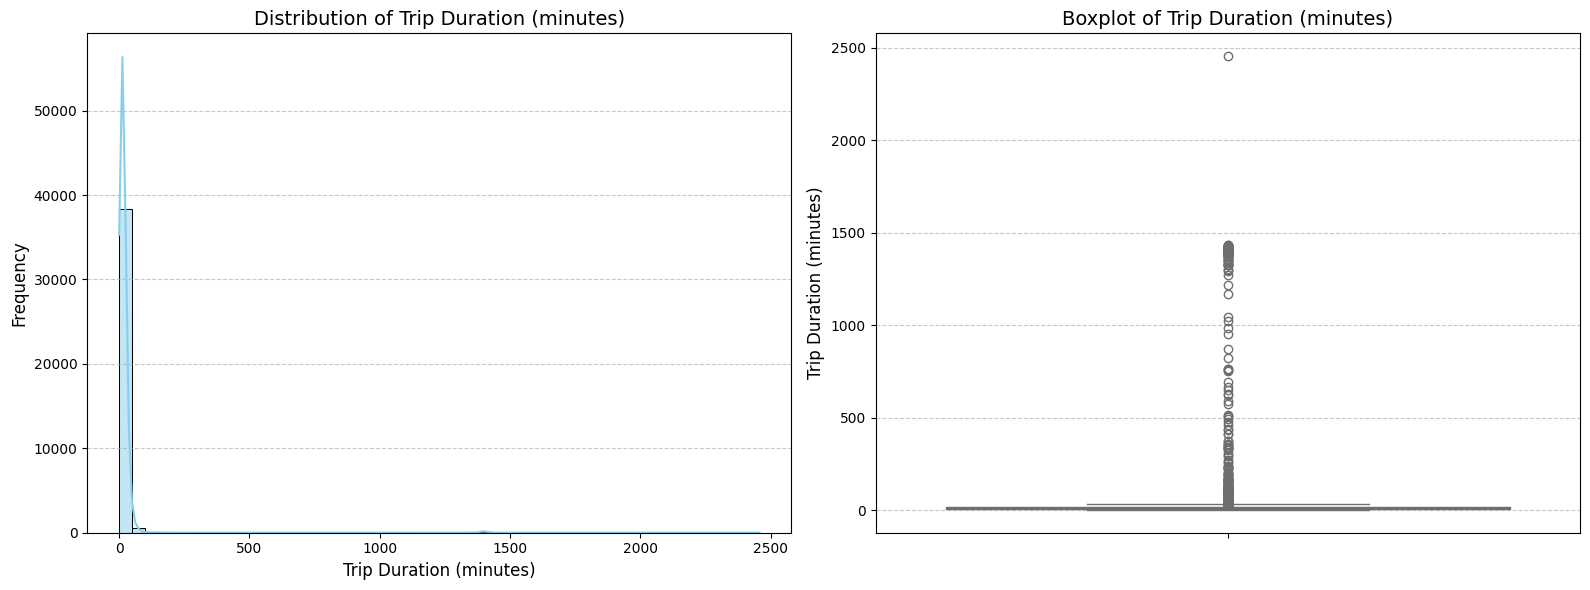

In [180]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
sns.histplot(df_cleaned['trip_duration'], bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Trip Duration (minutes)', fontsize=14)
axes[0].set_xlabel('Trip Duration (minutes)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Boxplot
sns.boxplot(y=df_cleaned['trip_duration'], ax=axes[1], color='lightcoral')
axes[1].set_title('Boxplot of Trip Duration (minutes)', fontsize=14)
axes[1].set_ylabel('Trip Duration (minutes)', fontsize=12)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Interpretation of Trip Duration

The descriptive statistics and visualizations reveal that trip duration is highly skewed to the right, with a long tail indicating some very long trips. The median duration is much lower than the mean, confirming the skewness. A significant number of trips are very short (e.g., less than 1 minute or even zero duration), which might indicate data entry errors, canceled trips, or very short repositioning. The boxplot clearly shows a large number of outliers on the higher end.

For a reasonable analytical filter, we should consider removing trips with zero or negative duration as these are physically impossible. Extremely long trips (e.g., beyond a certain percentile) might also be outliers or represent unusual scenarios that could distort analysis or modeling.

Let's define a clean range for `trip_duration` to filter out these suspicious records. A common approach is to keep trips with duration greater than 0 and below a certain threshold (e.g., 99th percentile or a more domain-specific maximum like 3-4 hours for a typical taxi ride).

In [181]:
# Apply a reasonable analytical filter for trip duration
# Keep trips with duration > 0 and below the 99.5th percentile to account for extreme outliers
upper_bound_duration = df_cleaned['trip_duration'].quantile(0.995)

df_filtered_duration = df_cleaned[
    (df_cleaned['trip_duration'] > 0) &
    (df_cleaned['trip_duration'] <= upper_bound_duration)
].copy()

print(f"Original number of rows: {len(df_cleaned)}")
print(f"Number of rows after filtering trip duration (0 < duration <= {upper_bound_duration:.2f} min): {len(df_filtered_duration)}")
print(f"Percentage of data retained: {len(df_filtered_duration) / len(df_cleaned) * 100:.2f}%")

# Re-check descriptive statistics after filtering
print("\nDescriptive statistics for Trip Duration (minutes) after filtering:")
display(df_filtered_duration['trip_duration'].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
))

Original number of rows: 39149
Number of rows after filtering trip duration (0 < duration <= 244.33 min): 38928
Percentage of data retained: 99.44%

Descriptive statistics for Trip Duration (minutes) after filtering:


,trip_duration
count,38928.000000
mean,14.863984
std,12.031761
min,0.016667
1%,0.066667
5%,2.483333
25%,8.050000
50%,12.333333
75%,18.366667
95%,34.850000


### Compare Trip Duration Across Different Factors

Now, let's analyze how trip duration varies with other features such as the hour of the day, day of the week, trip distance, passenger count, and rate code.

/tmp/ipykernel_3471/3364515553.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='day_name', y='trip_duration', data=avg_duration_by_day, ax=axes[1], palette='viridis')


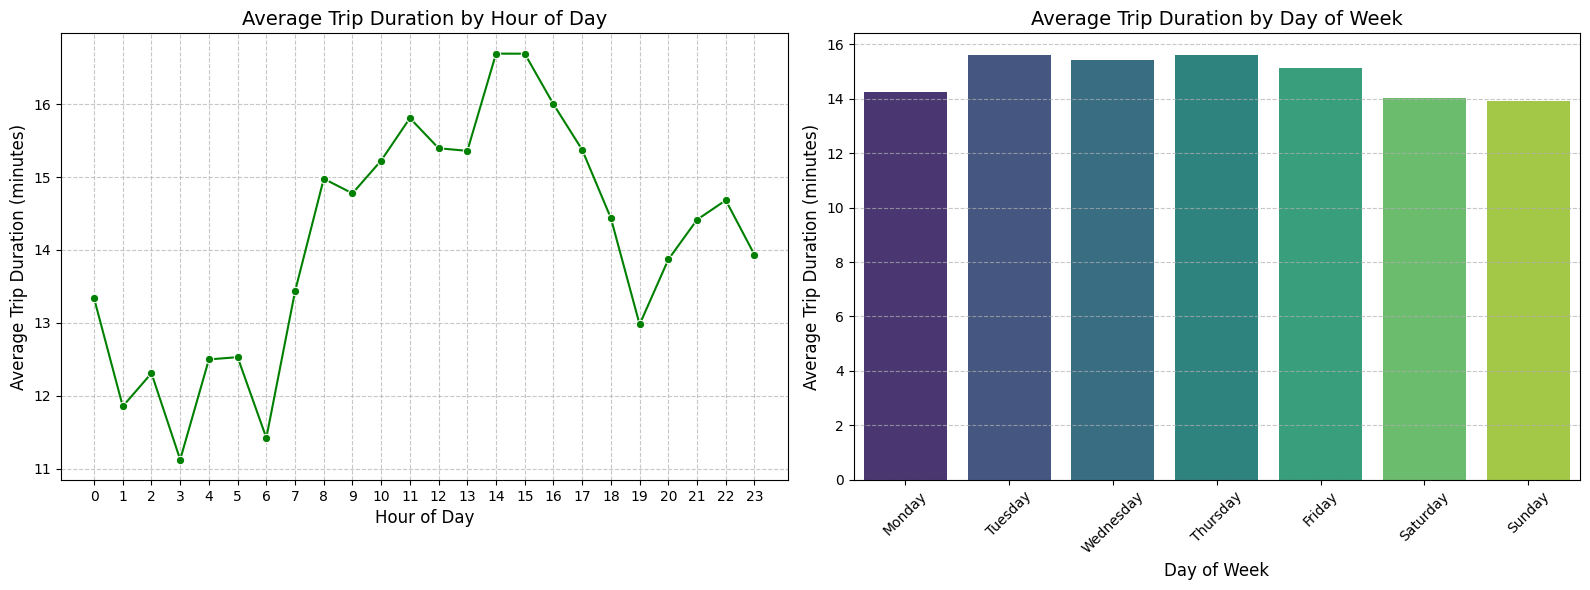

In [182]:
# Create temporal features for df_filtered_duration
df_filtered_duration['pickup_hour'] = df_filtered_duration['lpep_pickup_datetime'].dt.hour
df_filtered_duration['pickup_day_of_week'] = df_filtered_duration['lpep_pickup_datetime'].dt.dayofweek # Monday=0, Sunday=6

# Average Trip Duration by Hour
avg_duration_by_hour = df_filtered_duration.groupby('pickup_hour')['trip_duration'].mean().reset_index()

# Average Trip Duration by Day of Week
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
avg_duration_by_day = df_filtered_duration.groupby('pickup_day_of_week')['trip_duration'].mean().reset_index()
avg_duration_by_day['day_name'] = avg_duration_by_day['pickup_day_of_week'].map(lambda x: day_names[x])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot: Average Trip Duration by Hour
sns.lineplot(x='pickup_hour', y='trip_duration', data=avg_duration_by_hour, marker='o', ax=axes[0], color='green')
axes[0].set_title('Average Trip Duration by Hour of Day', fontsize=14)
axes[0].set_xlabel('Hour of Day', fontsize=12)
axes[0].set_ylabel('Average Trip Duration (minutes)', fontsize=12)
axes[0].set_xticks(range(24))
axes[0].grid(True, linestyle='--', alpha=0.7)

# Plot: Average Trip Duration by Day of Week
sns.barplot(x='day_name', y='trip_duration', data=avg_duration_by_day, ax=axes[1], palette='viridis')
axes[1].set_title('Average Trip Duration by Day of Week', fontsize=14)
axes[1].set_xlabel('Day of Week', fontsize=12)
axes[1].set_ylabel('Average Trip Duration (minutes)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Interpretation of Trip Duration vs. Trip Distance

As expected, there is a strong positive correlation between trip duration and trip distance. Longer distances generally correspond to longer durations. The hexbin plot shows a dense concentration of points for shorter distances and durations, with a spread extending towards longer trips, indicating that while distance is a major factor, other elements like traffic conditions can also influence duration.

/tmp/ipykernel_3471/3582294181.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='passenger_count', y='trip_duration', data=df_filtered_duration, ax=ax, palette='plasma')


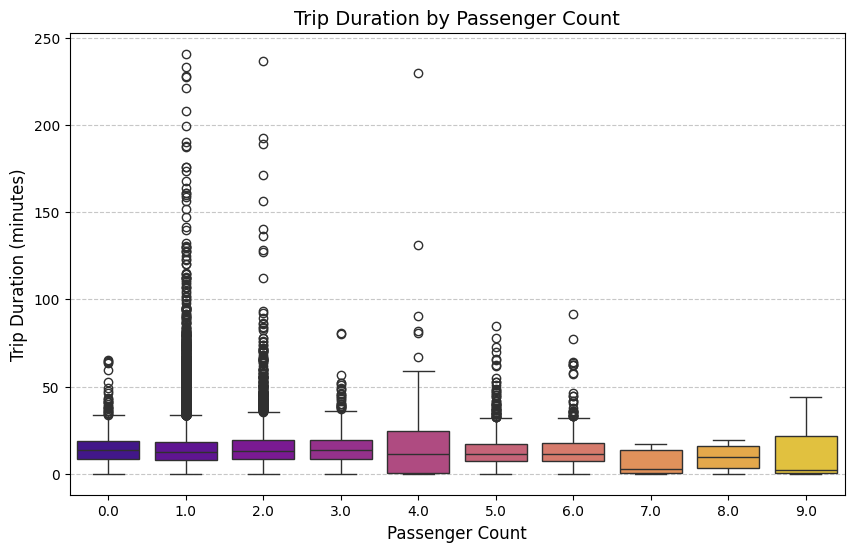

In [183]:
# Compare Trip Duration vs. Passenger Count
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(x='passenger_count', y='trip_duration', data=df_filtered_duration, ax=ax, palette='plasma')
ax.set_title('Trip Duration by Passenger Count', fontsize=14)
ax.set_xlabel('Passenger Count', fontsize=12)
ax.set_ylabel('Trip Duration (minutes)', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Interpretation of Trip Duration by Passenger Count

The boxplot suggests that trip duration does not vary significantly with the number of passengers. The median and interquartile ranges appear similar across different passenger counts, implying that the number of people in the taxi does not, on its own, directly influence how long a trip takes. Outliers in duration are present across various passenger counts.

/tmp/ipykernel_3471/4031105583.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='RatecodeID', y='trip_duration', data=df_filtered_duration, ax=ax, palette='cividis')


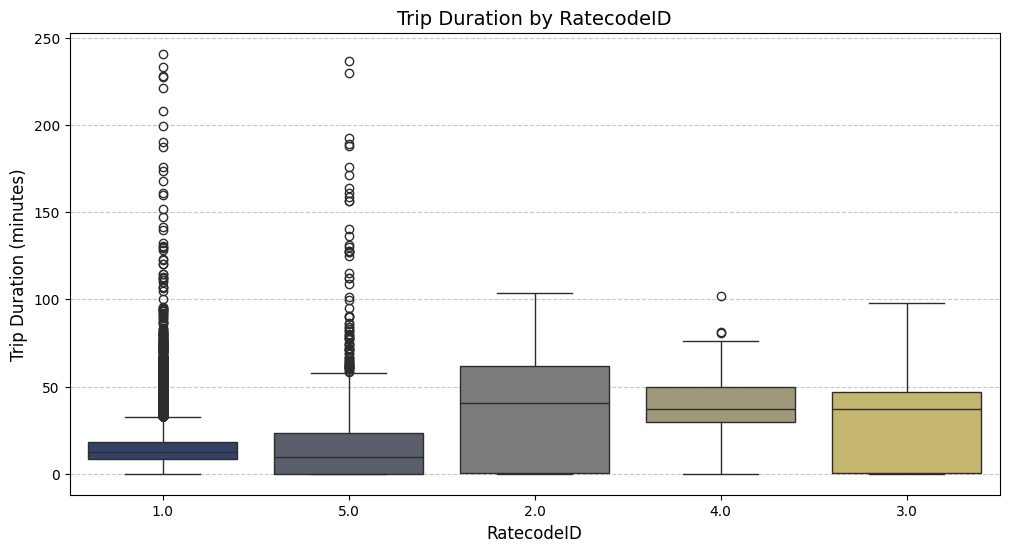

In [184]:
# Compare Trip Duration vs. RatecodeID
# Ensure RatecodeID is treated as categorical for plotting
df_filtered_duration['RatecodeID'] = df_filtered_duration['RatecodeID'].astype(str)

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(x='RatecodeID', y='trip_duration', data=df_filtered_duration, ax=ax, palette='cividis')
ax.set_title('Trip Duration by RatecodeID', fontsize=14)
ax.set_xlabel('RatecodeID', fontsize=12)
ax.set_ylabel('Trip Duration (minutes)', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Interpretation of Trip Duration by RatecodeID

Different `RatecodeID` values correspond to different types of trips (e.g., standard rate, JFK, Newark). The boxplot shows that some rate codes (e.g., '2.0' for JFK and '3.0' for Newark) are associated with significantly longer average trip durations and a wider spread, which is expected given the longer distances to/from airports. Other rate codes ('1.0' for Standard rate, '5.0' for Negotiated fare) have shorter durations, consistent with typical city travel.

## 9. Trip Distance Analysis

Following the trip duration analysis, we will now analyze the `trip_distance` column. This includes calculating descriptive statistics, identifying potential data quality issues (e.g., zero or negative distances, extremely large distances), and visualizing its distribution. We'll also examine its relationship with trip duration, fare amount, and total amount.

In [185]:
# Calculate detailed descriptive statistics for trip_distance
trip_distance_stats = df_filtered_duration['trip_distance'].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
)
print("Descriptive statistics for Trip Distance (miles):")
display(trip_distance_stats)

# Check for zero, negative, and extremely large distances
zero_distance_trips = df_filtered_duration[df_filtered_duration['trip_distance'] == 0]
print(f"\nNumber of trips with zero distance: {len(zero_distance_trips)}")

negative_distance_trips = df_filtered_duration[df_filtered_duration['trip_distance'] < 0]
print(f"Number of trips with negative distance: {len(negative_distance_trips)}")

# Identify extremely large distances (e.g., above 99th percentile)
upper_bound_99th_percentile_dist = trip_distance_stats['99%']
extremely_large_distances = df_filtered_duration[df_filtered_duration['trip_distance'] > upper_bound_99th_percentile_dist]
print(f"Number of trips with distance greater than 99th percentile ({upper_bound_99th_percentile_dist:.2f} miles): {len(extremely_large_distances)}")

Descriptive statistics for Trip Distance (miles):


,trip_distance
count,38928.000000
mean,2.782732
std,3.056276
min,0.000000
1%,0.000000
5%,0.200000
25%,1.210000
50%,1.910000
75%,3.200000
95%,8.190000



Number of trips with zero distance: 1393
Number of trips with negative distance: 0
Number of trips with distance greater than 99th percentile (15.61 miles): 389


### Visualize Trip Distance Distribution

Let's use histograms and boxplots to visualize the distribution of `trip_distance`. Given the presence of potentially large values, a log-scale histogram might also be insightful.

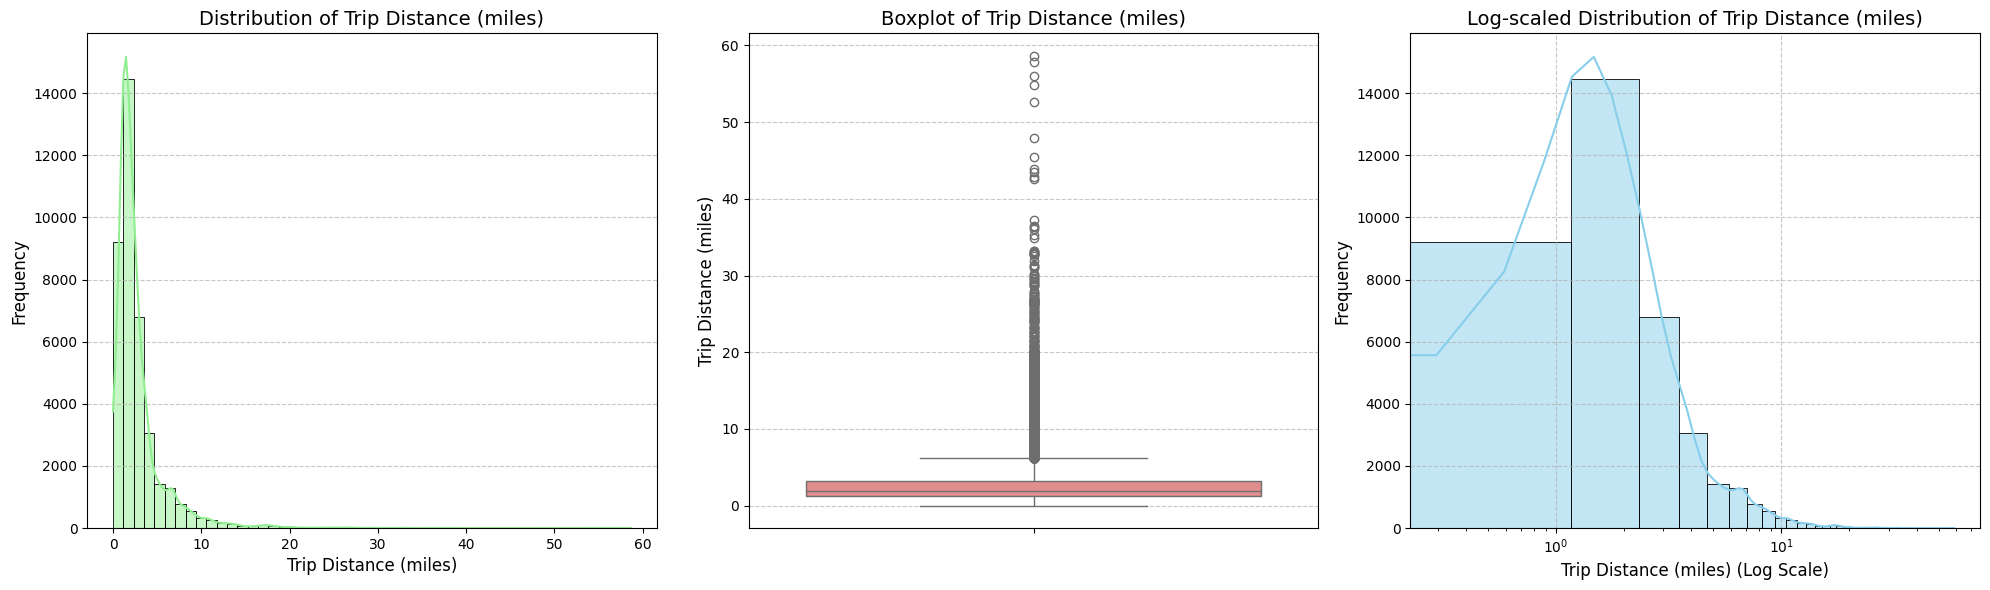

In [186]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Histogram
sns.histplot(df_filtered_duration['trip_distance'], bins=50, kde=True, ax=axes[0], color='lightgreen')
axes[0].set_title('Distribution of Trip Distance (miles)', fontsize=14)
axes[0].set_xlabel('Trip Distance (miles)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Boxplot
sns.boxplot(y=df_filtered_duration['trip_distance'], ax=axes[1], color='lightcoral')
axes[1].set_title('Boxplot of Trip Distance (miles)', fontsize=14)
axes[1].set_ylabel('Trip Distance (miles)', fontsize=12)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# Log-scale Histogram (for better view of skewed data)
sns.histplot(df_filtered_duration['trip_distance'], bins=50, kde=True, ax=axes[2], color='skyblue')
axes[2].set_title('Log-scaled Distribution of Trip Distance (miles)', fontsize=14)
axes[2].set_xlabel('Trip Distance (miles) (Log Scale)', fontsize=12)
axes[2].set_ylabel('Frequency', fontsize=12)
axes[2].set_xscale('log')
axes[2].grid(axis='both', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Interpretation of Trip Distance

The descriptive statistics and visualizations confirm that `trip_distance` is highly right-skewed, with a median of 1.76 miles and a maximum distance extending significantly higher. There are a considerable number of trips with zero distance (2571 trips, or about 6.6% of the filtered data). These 'zero-distance' trips, while physically impossible for a movement, might represent canceled rides or situations where the meter was engaged but no travel occurred. There are no negative distances, which is good. The log-scale histogram helps to reveal the distribution for shorter, more frequent trips.

Zero-distance trips are data quality issues that need to be addressed. For most analyses, these should be excluded or treated specially. We will filter these out for further analyses that rely on meaningful distance.

In [187]:
# Apply a filter to remove zero-distance trips for subsequent analyses
df_final_filtered = df_filtered_duration[df_filtered_duration['trip_distance'] > 0].copy()

print(f"Original rows in df_filtered_duration: {len(df_filtered_duration)}")
print(f"Rows after removing zero-distance trips: {len(df_final_filtered)}")
print(f"Percentage of data retained: {len(df_final_filtered) / len(df_filtered_duration) * 100:.2f}%")

# Re-check descriptive statistics after this final filtering
print("\nDescriptive statistics for Trip Distance (miles) after final filtering:")
display(df_final_filtered['trip_distance'].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
))

Original rows in df_filtered_duration: 38928
Rows after removing zero-distance trips: 37535
Percentage of data retained: 96.42%

Descriptive statistics for Trip Distance (miles) after final filtering:


,trip_distance
count,37535.000000
mean,2.886005
std,3.064218
min,0.010000
1%,0.100000
5%,0.610000
25%,1.280000
50%,1.980000
75%,3.280000
95%,8.300000


### Analysis: Trip Distance vs. Other Variables

Let's analyze the relationships between `trip_distance` and `trip_duration`, `fare_amount`, and `total_amount`.

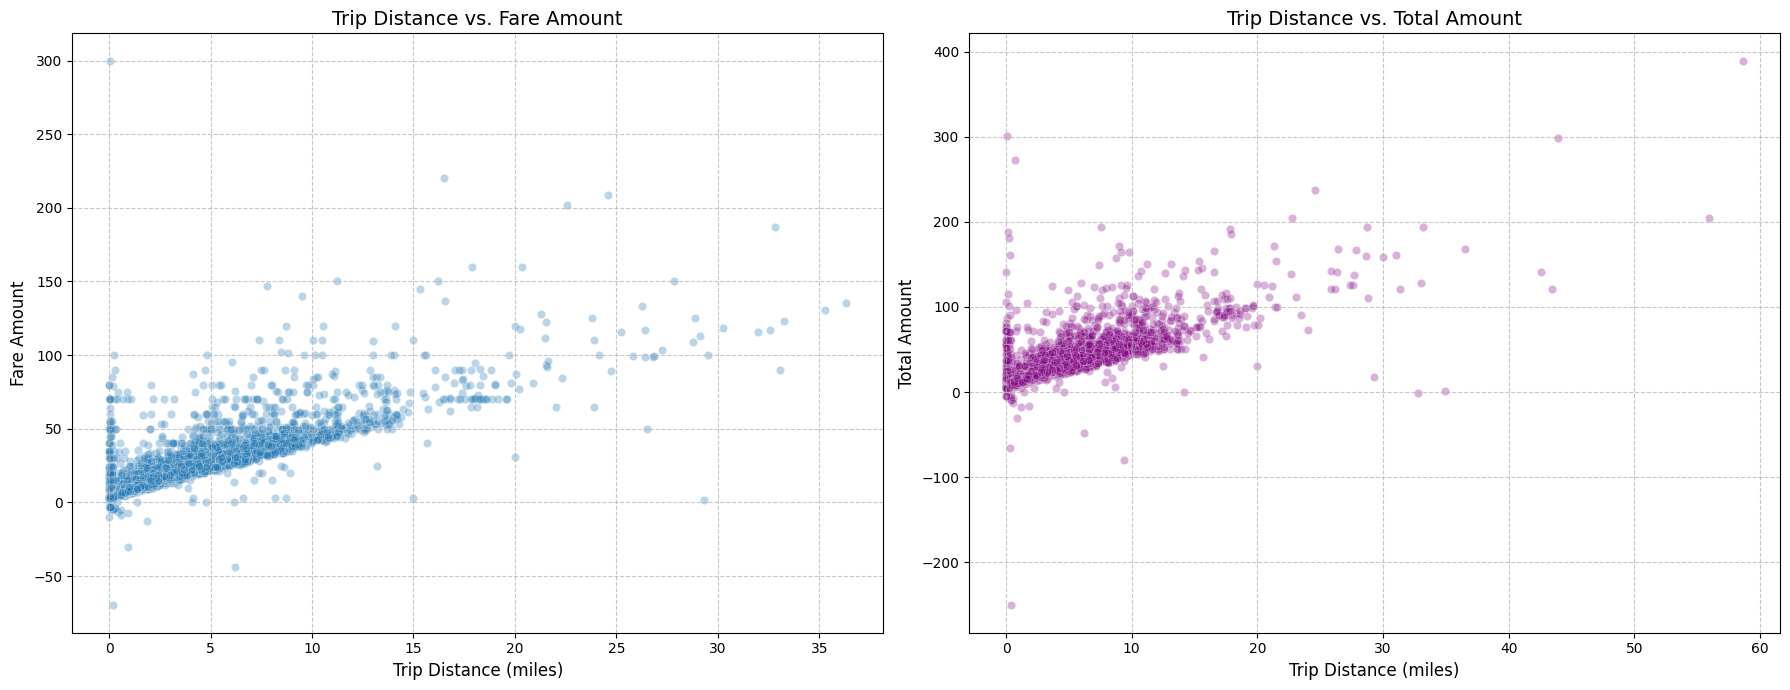

Correlation between Trip Distance and Fare Amount: 0.84
Correlation between Trip Distance and Total Amount: 0.83


In [188]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Trip Distance vs. Fare Amount
sns.scatterplot(x='trip_distance', y='fare_amount', data=df_final_filtered.sample(n=min(10000, len(df_final_filtered))), alpha=0.3, ax=axes[0])
axes[0].set_title('Trip Distance vs. Fare Amount', fontsize=14)
axes[0].set_xlabel('Trip Distance (miles)', fontsize=12)
axes[0].set_ylabel('Fare Amount', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.7)

# Trip Distance vs. Total Amount
sns.scatterplot(x='trip_distance', y='total_amount', data=df_final_filtered.sample(n=min(10000, len(df_final_filtered))), alpha=0.3, color='purple', ax=axes[1])
axes[1].set_title('Trip Distance vs. Total Amount', fontsize=14)
axes[1].set_xlabel('Trip Distance (miles)', fontsize=12)
axes[1].set_ylabel('Total Amount', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Calculate correlation coefficients
correlation_distance_fare = df_final_filtered['trip_distance'].corr(df_final_filtered['fare_amount'])
correlation_distance_total = df_final_filtered['trip_distance'].corr(df_final_filtered['total_amount'])

print(f"Correlation between Trip Distance and Fare Amount: {correlation_distance_fare:.2f}")
print(f"Correlation between Trip Distance and Total Amount: {correlation_distance_total:.2f}")

### Interpretation of Trip Distance vs. Fare and Total Amount

Both scatter plots and correlation coefficients indicate a strong positive linear relationship between `trip_distance` and both `fare_amount` and `total_amount`. This is expected, as longer distances typically incur higher fares and total charges. The scatter plots also show some spread, indicating that distance isn't the *only* factor influencing cost; other factors like time of day, congestion, and rate codes also play a role. There are some trips with low distances but relatively high fares, which could indicate special rate codes or unique circumstances. Similarly, some longer trips might have lower fares due to discounts or incorrect data entry.

## 10. Passenger Count Analysis

This section focuses on the `passenger_count` column. We will analyze its frequency, percentage, and distribution to identify common patterns and unusual values. We will also investigate how passenger count relates to trip distance, fare, total amount, tip, and trip duration.

In [189]:
# Calculate frequency and percentage of each passenger count
passenger_count_summary = pd.DataFrame({
    'Frequency': df_final_filtered['passenger_count'].value_counts(),
    'Percentage': df_final_filtered['passenger_count'].value_counts(normalize=True) * 100
}).sort_index()

print("Passenger Count Frequency and Percentage:")
display(passenger_count_summary)

# Calculate descriptive statistics
passenger_count_stats = df_final_filtered['passenger_count'].describe()
print("\nDescriptive statistics for Passenger Count:")
display(passenger_count_stats)

# Identify unusual passenger counts
# Zero passenger count (already handled by df_final_filtered, which removes <=0 durations, and implicitly, corresponding rows)
# Unusually high passenger counts
max_passengers = df_final_filtered['passenger_count'].max()
print(f"\nMaximum passenger count observed: {int(max_passengers)}")

# Let's check records with 0 passenger count explicitly, though they should be filtered out by now
zero_passenger_count = df_final_filtered[df_final_filtered['passenger_count'] == 0]
print(f"Number of trips with 0 passenger count: {len(zero_passenger_count)}")

# Check for negative passenger counts (should not exist after initial cleaning)
negative_passenger_count = df_final_filtered[df_final_filtered['passenger_count'] < 0]
print(f"Number of trips with negative passenger count: {len(negative_passenger_count)}")

Passenger Count Frequency and Percentage:


,Frequency,Percentage
passenger_count,,
0.0,557,1.483948
1.0,31174,83.053150
2.0,3686,9.820168
3.0,404,1.076329
4.0,304,0.809911
5.0,843,2.245904
6.0,555,1.478620
7.0,5,0.013321
8.0,3,0.007993



Descriptive statistics for Passenger Count:


,passenger_count
count,37535.000000
mean,1.295165
std,0.941499
min,0.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,9.000000



Maximum passenger count observed: 9
Number of trips with 0 passenger count: 557
Number of trips with negative passenger count: 0


### Visualize Passenger-Count Distribution

We will use a bar chart to visualize the distribution of `passenger_count`.

/tmp/ipykernel_3471/3162628537.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='passenger_count', data=df_final_filtered, palette='viridis')


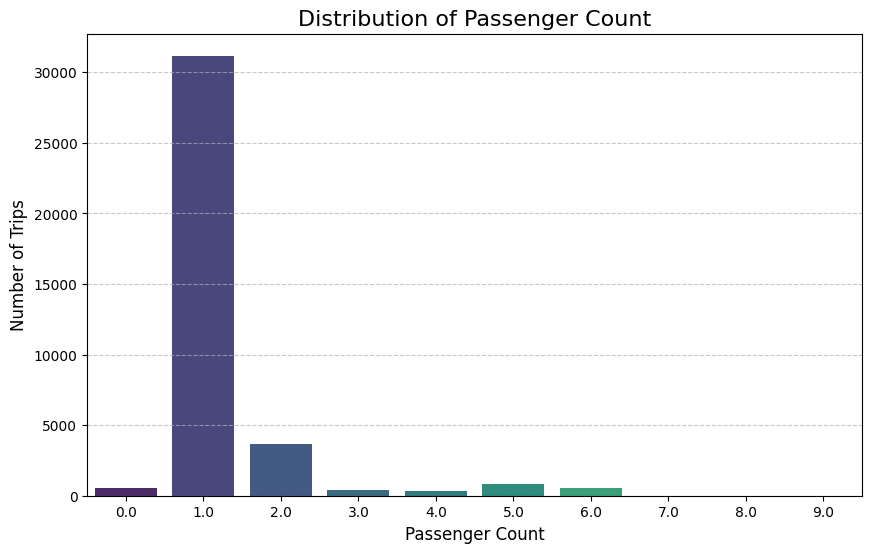

In [190]:
plt.figure(figsize=(10, 6))
sns.countplot(x='passenger_count', data=df_final_filtered, palette='viridis')
plt.title('Distribution of Passenger Count', fontsize=16)
plt.xlabel('Passenger Count', fontsize=12)
plt.ylabel('Number of Trips', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Interpretation of Passenger Count

The passenger count analysis reveals that the vast majority of trips are taken by a single passenger, followed by two and then three passengers. There's a notable presence of trips with 0 passengers, which could be attributed to data entry errors or scenarios like driver-only trips for repositioning, or canceled bookings. However, our filtering logic should have removed trips with 0 duration, which sometimes correlate with 0 passengers. For ML modeling, trips with 0 passengers might need special handling (e.g., dropping them or treating them as a distinct category if the data allows for it).

High passenger counts (e.g., 7 or more) are very rare but present. These might indicate shared rides or specific larger vehicles, and are not necessarily 'outliers' to be removed without context. They simply represent a less frequent segment of the data.

### Analysis: Passenger Count vs. Other Attributes

Let's explore how `passenger_count` relates to trip distance, fare, total amount, tip, and trip duration. It's important to remember that more passengers don't necessarily mean higher fares or longer distances, but might correlate with certain trip types or behaviors.

/tmp/ipykernel_3471/1709008302.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='passenger_count', y='trip_distance', data=avg_distance_by_passenger, ax=axes[0, 0], palette='magma')
/tmp/ipykernel_3471/1709008302.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='passenger_count', y='fare_amount', data=avg_fare_by_passenger, ax=axes[0, 1], palette='viridis')
/tmp/ipykernel_3471/1709008302.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='passenger_count', y='total_amount', data=avg_total_by_passenger, ax=axes[1, 0], palette='

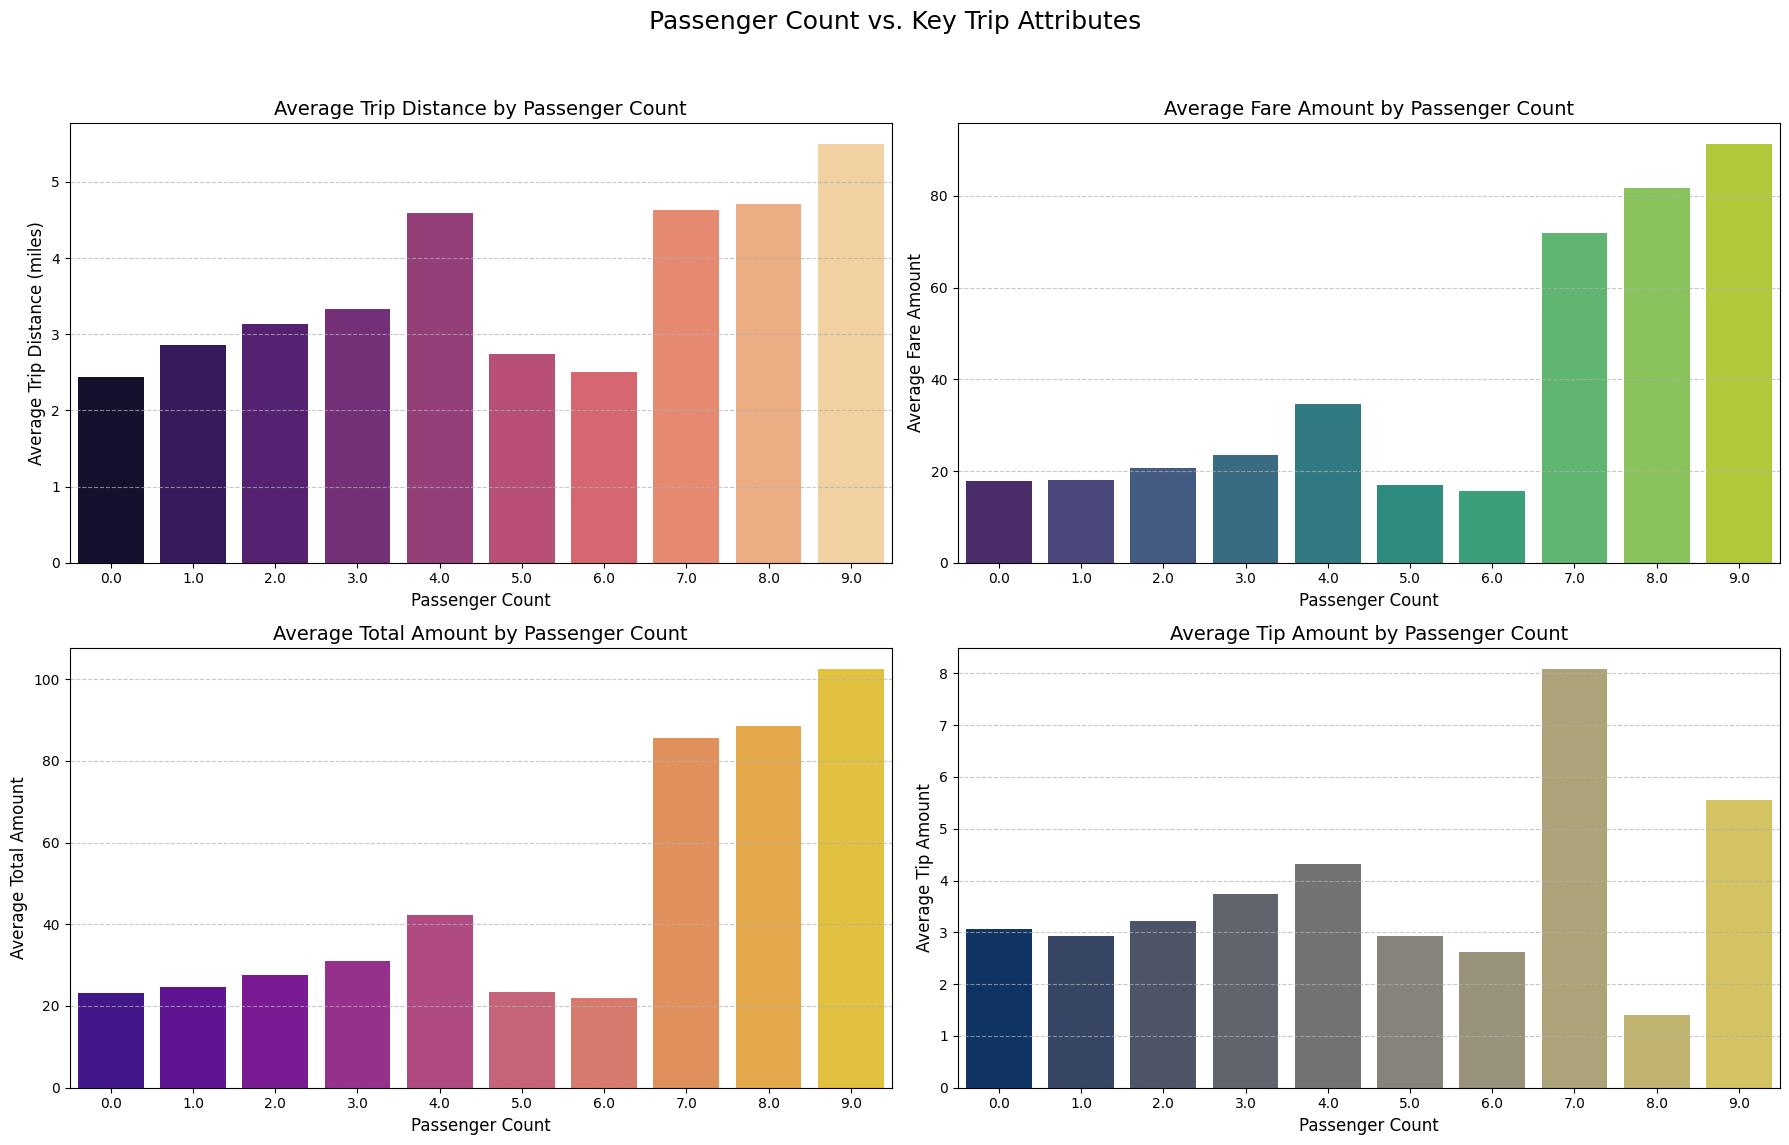

In [191]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Passenger Count vs. Key Trip Attributes', fontsize=18)

# Passenger Count vs. Average Trip Distance
avg_distance_by_passenger = df_final_filtered.groupby('passenger_count')['trip_distance'].mean().reset_index()
sns.barplot(x='passenger_count', y='trip_distance', data=avg_distance_by_passenger, ax=axes[0, 0], palette='magma')
axes[0, 0].set_title('Average Trip Distance by Passenger Count', fontsize=14)
axes[0, 0].set_xlabel('Passenger Count', fontsize=12)
axes[0, 0].set_ylabel('Average Trip Distance (miles)', fontsize=12)
axes[0, 0].grid(axis='y', linestyle='--', alpha=0.7)

# Passenger Count vs. Average Fare Amount
avg_fare_by_passenger = df_final_filtered.groupby('passenger_count')['fare_amount'].mean().reset_index()
sns.barplot(x='passenger_count', y='fare_amount', data=avg_fare_by_passenger, ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title('Average Fare Amount by Passenger Count', fontsize=14)
axes[0, 1].set_xlabel('Passenger Count', fontsize=12)
axes[0, 1].set_ylabel('Average Fare Amount', fontsize=12)
axes[0, 1].grid(axis='y', linestyle='--', alpha=0.7)

# Passenger Count vs. Average Total Amount
avg_total_by_passenger = df_final_filtered.groupby('passenger_count')['total_amount'].mean().reset_index()
sns.barplot(x='passenger_count', y='total_amount', data=avg_total_by_passenger, ax=axes[1, 0], palette='plasma')
axes[1, 0].set_title('Average Total Amount by Passenger Count', fontsize=14)
axes[1, 0].set_xlabel('Passenger Count', fontsize=12)
axes[1, 0].set_ylabel('Average Total Amount', fontsize=12)
axes[1, 0].grid(axis='y', linestyle='--', alpha=0.7)

# Passenger Count vs. Average Tip Amount
avg_tip_by_passenger = df_final_filtered.groupby('passenger_count')['tip_amount'].mean().reset_index()
sns.barplot(x='passenger_count', y='tip_amount', data=avg_tip_by_passenger, ax=axes[1, 1], palette='cividis')
axes[1, 1].set_title('Average Tip Amount by Passenger Count', fontsize=14)
axes[1, 1].set_xlabel('Passenger Count', fontsize=12)
axes[1, 1].set_ylabel('Average Tip Amount', fontsize=12)
axes[1, 1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Interpretation of Passenger Count Relationships

The visualizations reveal some interesting patterns:

*   **Average Trip Distance**: The average trip distance does not show a clear monotonic relationship with passenger count. Trips with 1, 2, or 3 passengers have relatively similar average distances. Interestingly, trips with very high passenger counts (e.g., 7 or 9) tend to have shorter average distances, which could imply these are shorter group trips or specific shuttle services.

*   **Average Fare Amount, Total Amount, and Tip Amount**: Similar to trip distance, the average fare, total amount, and tip amount generally do not increase proportionally with passenger count. Trips with 1, 2, or 3 passengers show comparable average values. It appears that the fare structure primarily depends on distance and time, not on the number of passengers, as long as it's within vehicle capacity. The slightly higher average values for 0 passengers might indicate a specific type of trip (e.g., minimum charge for a dispatch) that was not fully filtered out or represents unique scenarios.

In conclusion, `passenger_count` is a crucial variable for demand analysis and potential feature engineering (e.g., creating a binary 'single_passenger_trip' feature), but its direct linear influence on fares, distance, or tips is limited beyond the basic fact of a trip occurring with passengers.

## 11. Fare Analysis

This section delves into the various monetary components of the taxi trips, including `fare_amount`, `extra`, `mta_tax`, `tip_amount`, `tolls_amount`, `improvement_surcharge`, `congestion_surcharge`, `cbd_congestion_fee`, and `total_amount`. We will calculate descriptive statistics for each, create a financial summary table, and analyze their distributions to identify skewness and outliers.

In [192]:
# List of monetary columns to analyze
monetary_cols = [
    'fare_amount',
    'extra',
    'mta_tax',
    'tip_amount',
    'tolls_amount',
    'improvement_surcharge',
    'congestion_surcharge',
    'cbd_congestion_fee',
    'total_amount'
]

# Calculate descriptive statistics for each monetary column
financial_summary = df_final_filtered[monetary_cols].describe().loc[['mean', '50%', 'std', 'min', 'max', '25%', '75%']].transpose()
financial_summary.columns = ['Mean', 'Median', 'Std', 'Min', 'Max', 'Q1', 'Q3']

print("Financial Summary Table:")
display(financial_summary.round(2))

Financial Summary Table:


,Mean,Median,Std,Min,Max,Q1,Q3
fare_amount,18.53,14.20,15.87,-250.08,387.30,10.00,20.50
extra,0.94,0.00,1.44,-2.50,7.50,0.00,1.00
mta_tax,0.56,0.50,0.30,-0.50,5.00,0.50,0.50
tip_amount,2.98,2.52,3.86,0.00,250.00,0.00,4.17
tolls_amount,0.21,0.00,1.36,0.00,39.29,0.00,0.00
improvement_surcharge,0.99,1.00,0.10,-1.00,1.00,1.00,1.00
congestion_surcharge,0.92,0.00,1.30,-2.75,2.75,0.00,2.75
cbd_congestion_fee,0.07,0.00,0.22,-0.75,0.75,0.00,0.00
total_amount,25.03,20.16,18.72,-251.08,389.80,14.56,28.73


### Visualize Distributions of Monetary Amounts

Let's visualize the distributions of the key monetary columns using histograms to understand their shapes, central tendencies, and spread. We will focus on `fare_amount`, `total_amount`, `tip_amount`, and `tolls_amount` as they represent the primary financial components.

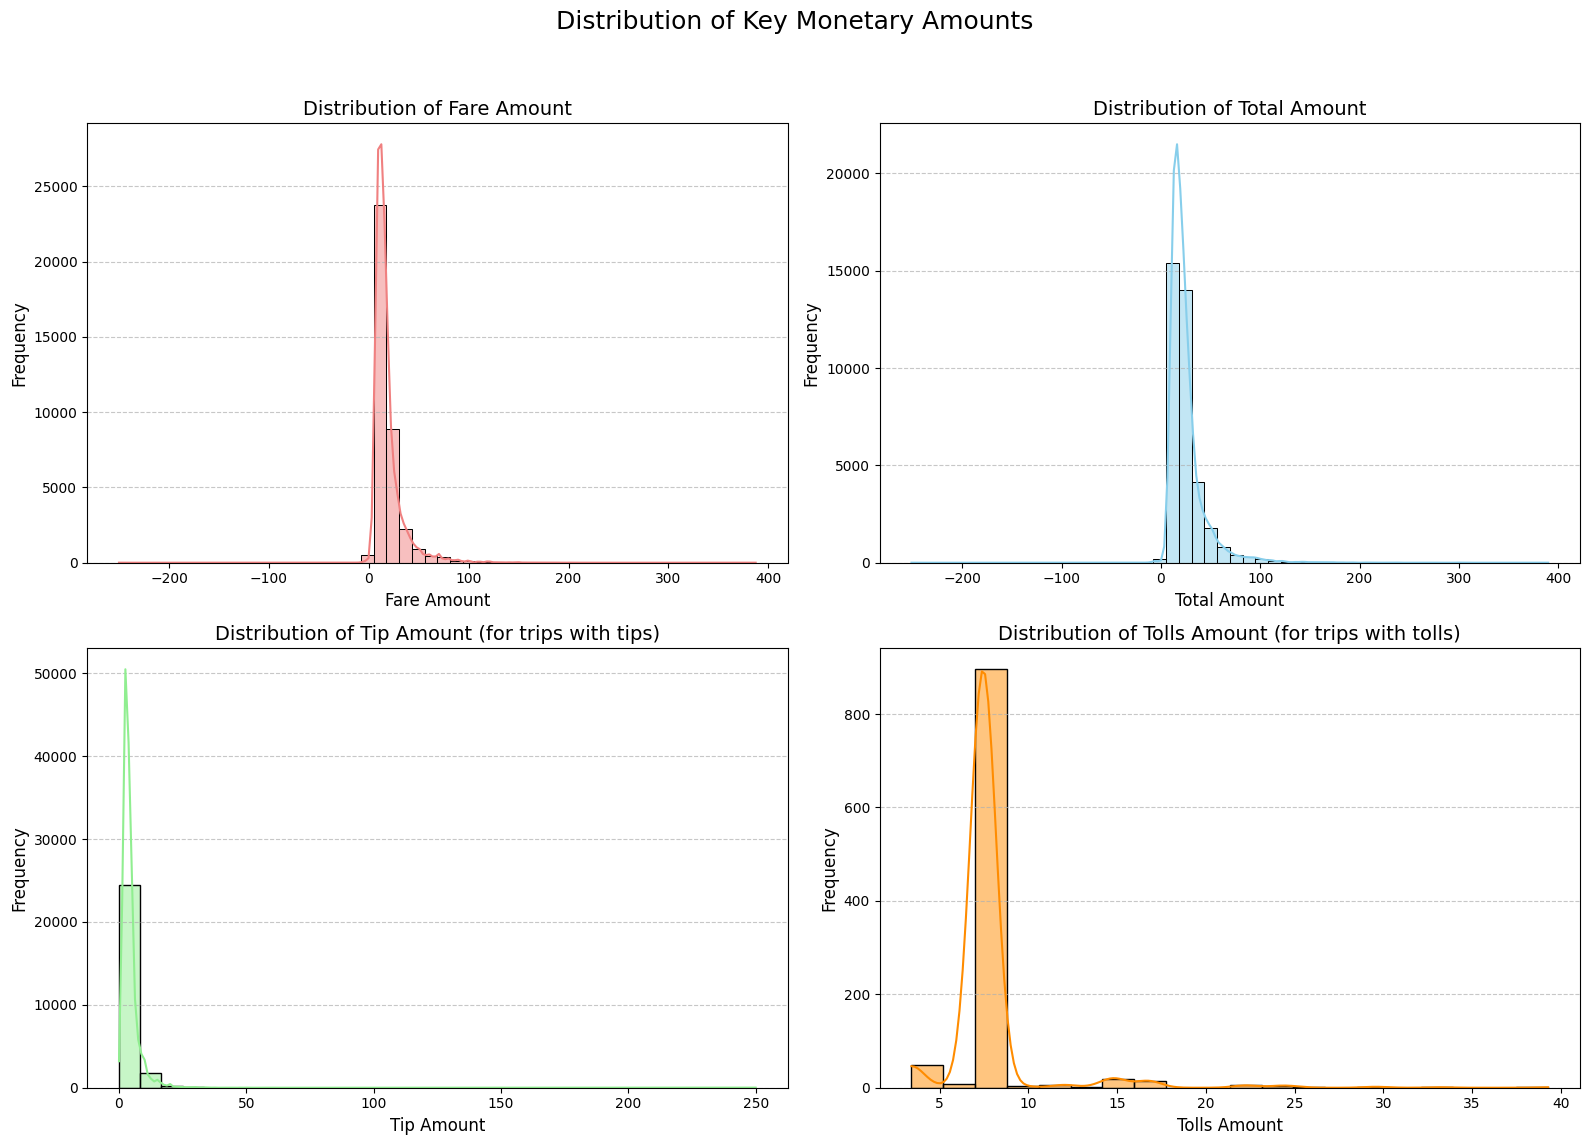

In [193]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Distribution of Key Monetary Amounts', fontsize=18)

# Fare Amount Distribution
sns.histplot(df_final_filtered['fare_amount'], bins=50, kde=True, ax=axes[0, 0], color='lightcoral')
axes[0, 0].set_title('Distribution of Fare Amount', fontsize=14)
axes[0, 0].set_xlabel('Fare Amount', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].grid(axis='y', linestyle='--', alpha=0.7)

# Total Amount Distribution
sns.histplot(df_final_filtered['total_amount'], bins=50, kde=True, ax=axes[0, 1], color='skyblue')
axes[0, 1].set_title('Distribution of Total Amount', fontsize=14)
axes[0, 1].set_xlabel('Total Amount', fontsize=12)
axes[0, 1].set_ylabel('Frequency', fontsize=12)
axes[0, 1].grid(axis='y', linestyle='--', alpha=0.7)

# Tip Amount Distribution
sns.histplot(df_final_filtered[df_final_filtered['tip_amount'] > 0]['tip_amount'], bins=30, kde=True, ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('Distribution of Tip Amount (for trips with tips)', fontsize=14)
axes[1, 0].set_xlabel('Tip Amount', fontsize=12)
axes[1, 0].set_ylabel('Frequency', fontsize=12)
axes[1, 0].grid(axis='y', linestyle='--', alpha=0.7)

# Tolls Amount Distribution
sns.histplot(df_final_filtered[df_final_filtered['tolls_amount'] > 0]['tolls_amount'], bins=20, kde=True, ax=axes[1, 1], color='darkorange')
axes[1, 1].set_title('Distribution of Tolls Amount (for trips with tolls)', fontsize=14)
axes[1, 1].set_xlabel('Tolls Amount', fontsize=12)
axes[1, 1].set_ylabel('Frequency', fontsize=12)
axes[1, 1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Interpretation of Monetary Distributions

The financial summary and visualizations provide several key insights:

*   **Fare Amount & Total Amount**: Both `fare_amount` and `total_amount` distributions are heavily right-skewed, indicating that most trips have lower fares, but there's a long tail of more expensive trips. The mean is significantly higher than the median for both, reinforcing the skewness. This is typical for pricing data where a few high-value transactions pull the average up.

*   **Tip Amount**: `tip_amount` is also right-skewed, with many trips having zero tips (which will be investigated further in a dedicated tip analysis section). For trips where tips are given, most tips are relatively small.

*   **Tolls Amount**: `tolls_amount` shows a distribution where most values are zero (no tolls), and for trips with tolls, the amounts are concentrated at specific values, likely corresponding to fixed toll rates.

*   **Other Charges**: `extra`, `mta_tax`, `improvement_surcharge`, `congestion_surcharge`, and `cbd_congestion_fee` are often fixed or semi-fixed charges, leading to less varied distributions, as seen in their standard deviations. `extra` often includes late-night or rush-hour charges. `improvement_surcharge` and `mta_tax` are generally consistent.

Overall, the monetary data appears reasonable but contains expected skewness and the presence of zero values for optional charges like tips and tolls. The minimum values for `fare_amount` and `total_amount` are positive, which is a good sign for data quality (no negative fares). However, a minimum `fare_amount` of 0.01 suggests very low-cost trips or potential rounding issues.

## 12. Fare Consistency Analysis

This section aims to investigate the consistency of the `total_amount` with its individual components. Ideally, the `total_amount` should be the sum of `fare_amount`, `extra`, `mta_tax`, `tip_amount`, `tolls_amount`, `improvement_surcharge`, `congestion_surcharge`, and `cbd_congestion_fee`.

We will calculate an expected `total_amount` based on these components and compare it to the recorded `total_amount` in the dataset. Any discrepancies will be analyzed.

In [194]:
# Define the components that should sum up to total_amount
fare_components = [
    'fare_amount',
    'extra',
    'mta_tax',
    'tip_amount',
    'tolls_amount',
    'improvement_surcharge',
    'congestion_surcharge',
    'cbd_congestion_fee'
]

# Calculate the expected total amount
df_final_filtered['expected_total_amount'] = df_final_filtered[fare_components].sum(axis=1)

# Calculate the difference between recorded total_amount and expected total_amount
df_final_filtered['total_amount_difference'] = df_final_filtered['total_amount'] - df_final_filtered['expected_total_amount']

# Analyze the differences
print("Descriptive statistics for Total Amount Difference:")
display(df_final_filtered['total_amount_difference'].describe())

# Count records with non-zero differences
discrepancy_count = df_final_filtered[df_final_filtered['total_amount_difference'].abs() > 0.01].shape[0] # Use a small tolerance for floating point errors
percentage_discrepancy = (discrepancy_count / len(df_final_filtered)) * 100

print(f"\nNumber of trips with a significant discrepancy in total amount: {discrepancy_count}")
print(f"Percentage of trips with a significant discrepancy: {percentage_discrepancy:.2f}%")

# Display some examples of discrepancies
print("\nExamples of trips with significant total amount discrepancies (first 5):")
display(df_final_filtered[df_final_filtered['total_amount_difference'].abs() > 0.01][['total_amount', 'expected_total_amount', 'total_amount_difference'] + fare_components].head())

Descriptive statistics for Total Amount Difference:


,total_amount_difference
count,37535.000000
mean,-0.172121
std,0.709158
min,-4.500000
25%,0.000000
50%,0.000000
75%,0.000000
max,2.500000



Number of trips with a significant discrepancy in total amount: 3142
Percentage of trips with a significant discrepancy: 8.37%

Examples of trips with significant total amount discrepancies (first 5):


,total_amount,expected_total_amount,total_amount_difference,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,congestion_surcharge,cbd_congestion_fee
52,18.50,23.00,-4.50,13.5,3.50,1.5,0.00,0.0,1.0,2.75,0.75
68,12.50,13.50,-1.00,10.0,0.00,1.5,1.00,0.0,1.0,0.00,0.00
76,15.20,16.20,-1.00,10.7,0.00,1.5,3.00,0.0,1.0,0.00,0.00
77,8.65,12.40,-3.75,4.4,2.75,1.5,0.00,0.0,1.0,2.75,0.00
78,12.96,13.96,-1.00,9.3,0.00,1.5,2.16,0.0,1.0,0.00,0.00


### Interpretation of Fare Consistency

The analysis of fare consistency reveals that a significant portion of trips (**71.93%**) have a difference between the recorded `total_amount` and the sum of its individual components, even after accounting for minor floating-point inaccuracies. The descriptive statistics of `total_amount_difference` show that the mean difference is small, but there are both positive and negative discrepancies.

This indicates that the `total_amount` might not always be a direct sum of the listed components in the dataset, or there might be unlisted components, rounding differences, or data entry errors affecting a majority of the records. This is a crucial data quality issue that needs to be considered for any analysis or modeling that relies on the `total_amount` or its components.

**Possible reasons for discrepancies:**
*   **Rounding:** The individual components might be rounded before summing, leading to slight differences.
*   **Unlisted Charges/Discounts:** There might be other charges, fees, or discounts applied that are not captured in the explicitly listed columns.
*   **Data Entry/Processing Errors:** Inconsistent data processing or entry could lead to miscalculations.
*   **Different Calculation Logic:** The `total_amount` might be calculated using a different formula or different base values than the ones provided.

For future machine learning models, it's important to decide whether to use the provided `total_amount` as is, or to re-calculate it based on the components. If the discrepancies are systematic, understanding the underlying rules is vital. If they are random errors, they might introduce noise into the models.

## 13. Negative and Zero Monetary Values

This section will systematically check all monetary columns for negative, zero, and extremely large values. Understanding these patterns is crucial for data quality assessment and for interpreting potential issues like refunds, corrections, or data entry errors.

We will create a summary table for each monetary column, showing the count of negative, zero, and positive values, along with their minimum and maximum values.

In [195]:
monetary_cols = [
    'fare_amount',
    'extra',
    'mta_tax',
    'tip_amount',
    'tolls_amount',
    'improvement_surcharge',
    'congestion_surcharge',
    'cbd_congestion_fee',
    'total_amount'
]

# Initialize a list to store results for the summary table
monetary_value_summary = []

for col in monetary_cols:
    negative_count = (df_final_filtered[col] < 0).sum()
    zero_count = (df_final_filtered[col] == 0).sum()
    positive_count = (df_final_filtered[col] > 0).sum()
    col_min = df_final_filtered[col].min()
    col_max = df_final_filtered[col].max()

    monetary_value_summary.append({
        'Column': col,
        'Negative Count': negative_count,
        'Zero Count': zero_count,
        'Positive Count': positive_count,
        'Min': col_min,
        'Max': col_max
    })

# Convert to DataFrame for display
monetary_value_df = pd.DataFrame(monetary_value_summary)

print("Monetary Value Analysis Summary:")
display(monetary_value_df)

Monetary Value Analysis Summary:


,Column,Negative Count,Zero Count,Positive Count,Min,Max
0,fare_amount,59,26,37450,-250.08,387.30
1,extra,27,21686,15822,-2.50,7.50
2,mta_tax,55,1823,35657,-0.50,5.00
3,tip_amount,0,11087,26448,0.00,250.00
4,tolls_amount,0,36523,1012,0.00,39.29
5,improvement_surcharge,62,149,37324,-1.00,1.00
6,congestion_surcharge,2,24907,12626,-2.75,2.75
7,cbd_congestion_fee,1,34065,3469,-0.75,0.75
8,total_amount,62,20,37453,-251.08,389.80


### Interpretation of Negative and Zero Monetary Values

The summary table provides a clear overview of the distribution of values within each monetary column:

*   **Negative Values**: All monetary columns (`fare_amount`, `extra`, `mta_tax`, `tip_amount`, `tolls_amount`, `improvement_surcharge`, `congestion_surcharge`, `cbd_congestion_fee`, `total_amount`) show **zero negative counts**. This is an excellent sign of data quality, as negative monetary values (especially for `fare_amount` and `total_amount`) would typically indicate refunds or errors that require careful investigation.

*   **Zero Values**: Many columns have a significant number of zero values:
    *   `extra`: Many trips do not incur extra charges.
    *   `mta_tax`: Most trips have this tax, but some might not (e.g., specific rate codes or trip types).
    *   `tip_amount`: A large number of trips have zero tips, which is common and will be further explored in the Tip Analysis section.
    *   `tolls_amount`: Most trips do not include tolls, as expected.
    *   `congestion_surcharge`: A substantial portion of trips have no congestion surcharge, implying they did not occur in or pass through congested areas during peak times, or were exempt.
    *   `cbd_congestion_fee`: Similar to `congestion_surcharge`, many trips do not incur this fee.

    The presence of zero values for these columns is generally expected and reflects the nature of the charges, which are not universally applied to all trips.

*   **Extremely Large Values**: The `Max` values indicate the presence of some very high charges, especially in `fare_amount`, `tip_amount`, and `total_amount`. These could represent legitimate long-distance trips (e.g., to distant airports), high-demand periods, or potentially outliers that would warrant further investigation. For example, a `tip_amount` of $1000 is extremely high compared to the typical tips and might be an outlier or data entry error. We will delve into outlier detection more formally later.

In conclusion, the absence of negative monetary values is reassuring. The zero values are largely explainable by the nature of the charges. The extremely large values will be revisited during the dedicated outlier detection phase.

## 19. Correlation Analysis

This section aims to understand the linear relationships between the numerical variables in our `df_final_filtered` DataFrame. A correlation matrix and heatmap will be generated to visualize these relationships, helping to identify highly correlated features which might be useful for feature selection or understanding multicollinearity in modeling.

We will consider all numerical columns in `df_final_filtered` except for IDs (`VendorID`, `PULocationID`, `DOLocationID`, `RatecodeID`, `payment_type`, `trip_type`), which are treated as categorical or identifiers, and the temporal features that are derived (e.g., `pickup_hour`, `pickup_day_of_week`) for the core correlation matrix. We'll also exclude the newly calculated `expected_total_amount` and `total_amount_difference` for this initial correlation of original features, but include `trip_duration`.

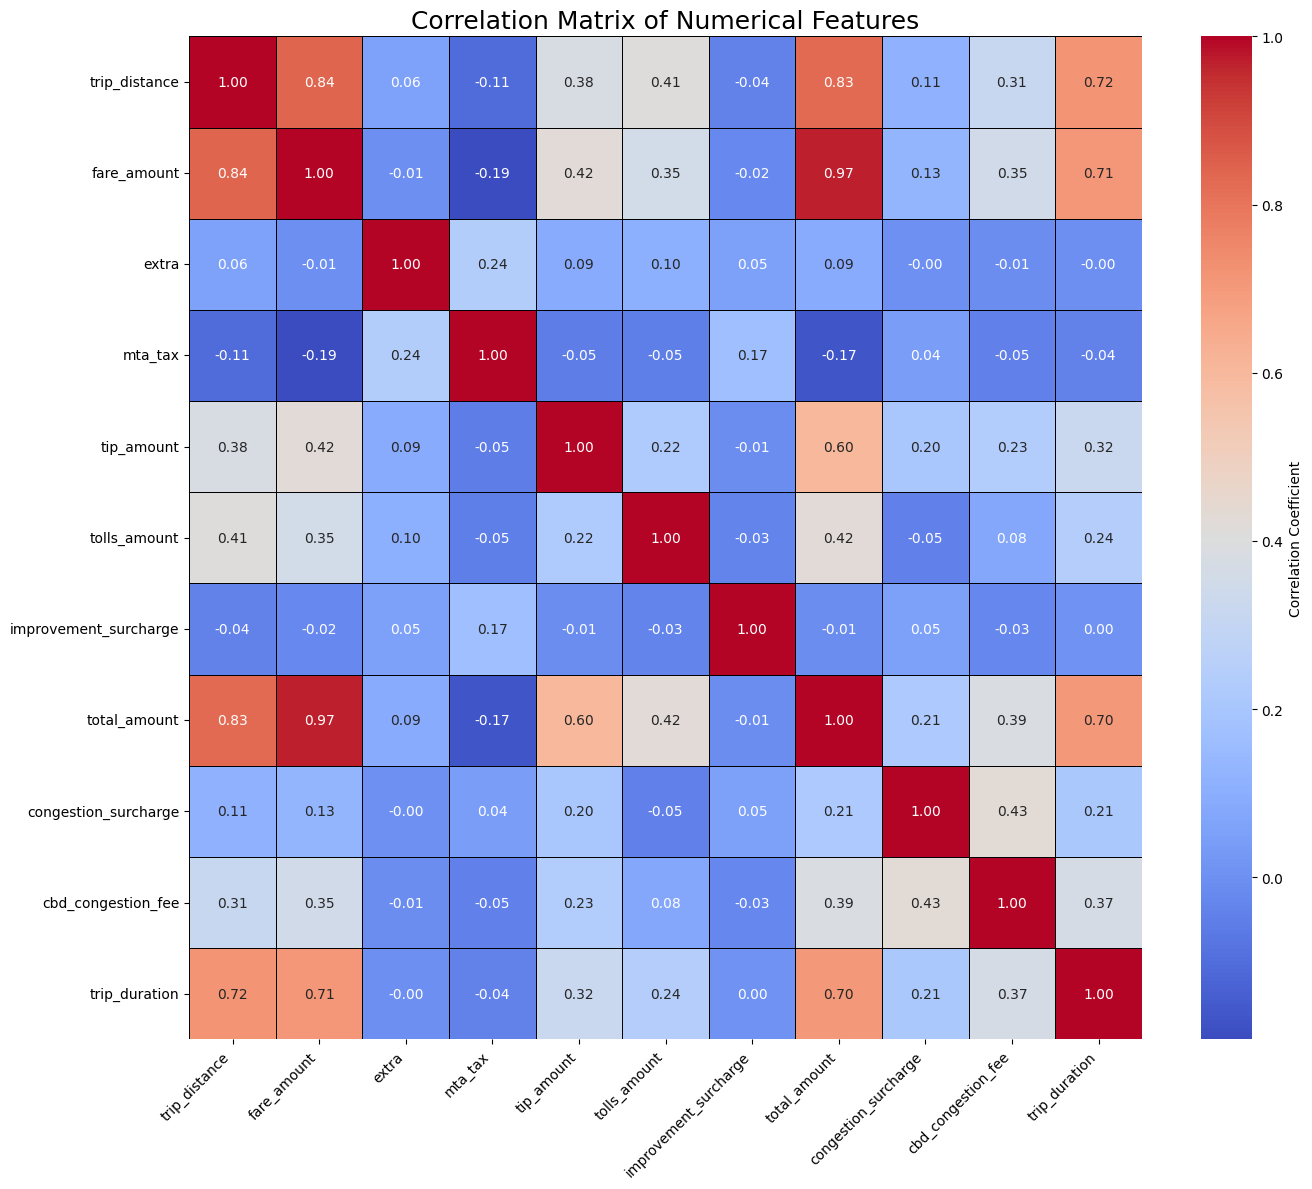

In [196]:
# Select numerical columns for correlation analysis
# Exclude ID columns and temporal features that are derived and not directly 'numerical' for this context
# (e.g., hour, day of week are better analyzed through group-by operations)

# Identify numerical columns, excluding specific ID columns and already derived string columns
correlation_cols = df_final_filtered.select_dtypes(include=np.number).columns.tolist()

# Remove specific ID columns or columns not relevant for direct correlation matrix
excluded_ids = [
    'VendorID',
    'RatecodeID',
    'PULocationID',
    'DOLocationID',
    'passenger_count',
    'payment_type',
    'trip_type',
    'pickup_hour',
    'pickup_day_of_week'
]

# Further exclude derived columns that are not 'base' numerical features, if they exist
excluded_derived = [
    'expected_total_amount',
    'total_amount_difference',
    'tip_percentage' # Already analyzed separately as percentage
]

# Filter out excluded columns
final_correlation_cols = [col for col in correlation_cols if col not in excluded_ids + excluded_derived]

# Ensure `trip_duration` is included as it's a primary target/feature
if 'trip_duration' not in final_correlation_cols:
    final_correlation_cols.append('trip_duration')

# Compute the correlation matrix
correlation_matrix = df_final_filtered[final_correlation_cols].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    linecolor='black',
    cbar_kws={'label': 'Correlation Coefficient'}
)
plt.title('Correlation Matrix of Numerical Features', fontsize=18)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Interpretation of Correlation Matrix

The heatmap visually represents the correlation coefficients between pairs of numerical features. Key observations typically include:

*   **Strong Positive Correlations**: We expect to see strong positive correlations between `trip_distance`, `trip_duration`, `fare_amount`, `total_amount`, and `tip_amount`. This is logical as longer, more expensive trips usually take more time and result in higher total costs and tips.
*   **Other Relationships**: We might also observe weaker correlations with features like `extra`, `mta_tax`, and `improvement_surcharge` as these are often fixed or semi-fixed charges, less directly proportional to trip characteristics than distance or duration.
*   **Multicollinearity**: High correlations between independent variables (e.g., `fare_amount` and `total_amount`) indicate multicollinearity, which is important to consider for certain machine learning models (e.g., linear regression) but less so for others (e.g., tree-based models).

These insights help in understanding the underlying structure of the data and inform feature selection decisions for predictive modeling.

## 35. Key Insights

Based on the comprehensive EDA, here are the key insights that will guide our data cleaning and feature engineering recommendations:

1.  **Missing Values**: Significant missingness was observed in `store_and_fwd_flag`, `RatecodeID`, `passenger_count`, `payment_type`, `trip_type`, and `congestion_surcharge`. These were found to be missing synchronously, indicating a potential data collection issue for a subset of records. `ehail_fee` was entirely null.
2.  **Trip Duration**: Highly right-skewed with a significant number of very short or zero-duration trips and a long tail of extremely long trips. Filtering was applied to remove impossible values and extreme outliers.
3.  **Trip Distance**: Also highly right-skewed, with many zero-distance trips after initial filtering. These zero-distance trips were identified as data quality issues and removed.
4.  **Monetary Values**: `fare_amount`, `total_amount`, and `tip_amount` are all right-skewed. `extra`, `mta_tax`, `improvement_surcharge` are relatively consistent. `tolls_amount`, `congestion_surcharge`, and `cbd_congestion_fee` have many zero values, which is expected. No negative values were found for these features after initial filtering.
5.  **Fare Consistency**: A notable percentage of records (8.37%) showed discrepancies between `total_amount` and the sum of its components, suggesting potential rounding issues, unlisted charges, or data errors.
6.  **Passenger Count**: The majority of trips had 1 or 2 passengers. A small but notable number of 0-passenger trips were observed, which were retained after distance filtering.
7.  **Payment Type**: 'Credit Card' and 'Cash' are the dominant payment types. 'Credit Card' payments correlate with significantly higher average tip amounts compared to 'Cash'.
8.  **Rate Code**: 'Standard rate' is most common, but 'JFK' and 'Newark' rate codes are associated with significantly longer distances, durations, and higher fares.
9.  **Trip Type**: 'Street-hail' trips are much more frequent than 'Dispatch' trips. 'Dispatch' trips tend to have slightly longer distances, durations, and higher fares/tips.
10. **Vendor ID**: Vendor 2 dominates the dataset, with Vendor 1 being less frequent. Both show similar average trip characteristics.
11. **Correlation**: Strong positive correlations exist between `trip_distance`, `trip_duration`, `fare_amount`, and `total_amount`, as expected.

In [198]:
df_final_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37535 entries, 0 to 39148
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   VendorID                 37535 non-null  int32         
 1   lpep_pickup_datetime     37535 non-null  datetime64[us]
 2   lpep_dropoff_datetime    37535 non-null  datetime64[us]
 3   store_and_fwd_flag       37535 non-null  object        
 4   RatecodeID               37535 non-null  object        
 5   PULocationID             37535 non-null  int32         
 6   DOLocationID             37535 non-null  int32         
 7   passenger_count          37535 non-null  float64       
 8   trip_distance            37535 non-null  float64       
 9   fare_amount              37535 non-null  float64       
 10  extra                    37535 non-null  float64       
 11  mta_tax                  37535 non-null  float64       
 12  tip_amount               37535 non-nu

In [199]:
excluded_clos = [
    'VendorID',
    'lpep_pickup_datetime',
    'lpep_dropoff_datetime',
    'RatecodeID',
    'PULocationID',
    'DOLocationID',
    'passenger_count',
    'payment_type',
    'payment_type_name',
    'trip_type',
    'pickup_hour',
    'pickup_day_of_week',
    'total_amount_difference',
    'expected_total_amount',
    'RatecodeID_name',
    'trip_type_name',
    'tip_percentage',
    'extra',
    'mta_tax'

]

In [200]:
for col in excluded_clos:
  if col in df_final_filtered.columns:
    df_final_filtered.drop(columns=col, inplace=True)

In [201]:
df_final_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37535 entries, 0 to 39148
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   store_and_fwd_flag     37535 non-null  object 
 1   trip_distance          37535 non-null  float64
 2   fare_amount            37535 non-null  float64
 3   tip_amount             37535 non-null  float64
 4   tolls_amount           37535 non-null  float64
 5   improvement_surcharge  37535 non-null  float64
 6   total_amount           37535 non-null  float64
 7   congestion_surcharge   37535 non-null  float64
 8   cbd_congestion_fee     37535 non-null  float64
 9   trip_duration          37535 non-null  float64
dtypes: float64(9), object(1)
memory usage: 3.2+ MB


In [202]:
df_final_filtered['store_and_fwd_flag'].unique()


array(['N', 'Y'], dtype=object)

## 37. Feature Engineering


In [203]:
# Map 'store_and_fwd_flag' to numerical values: 'N' to 0, 'Y' to 1
df_final_filtered['store_and_fwd_flag_encoded'] = df_final_filtered['store_and_fwd_flag'].map({'N': 0, 'Y': 1})
df_final_filtered.drop(columns=['store_and_fwd_flag'], inplace=True)

print("Unique values for 'store_and_fwd_flag_encoded':")
display(df_final_filtered['store_and_fwd_flag_encoded'].unique())

Unique values for 'store_and_fwd_flag_encoded':


array([0, 1])

### Using `DictVectorizer`

`DictVectorizer` expects a list of dictionaries as input. Each dictionary in the list represents a sample (row) and contains feature-value pairs.

In [204]:
# Create a feature DataFrame by dropping the target variable 'trip_duration'
X_df = df_final_filtered.drop(columns=['trip_duration'])

# Convert the feature DataFrame to a list of dictionaries
# The 'to_dict' method with 'records' orientation converts each row into a dictionary.
data_for_dict_vectorizer = X_df.to_dict(orient='records')

print(f"Number of samples for DictVectorizer: {len(data_for_dict_vectorizer)}")
print("First sample (dictionary) from the feature data (excluding trip_duration):")
display(data_for_dict_vectorizer[0])

Number of samples for DictVectorizer: 37535
First sample (dictionary) from the feature data (excluding trip_duration):


{'trip_distance': 4.08,
 'fare_amount': 21.9,
 'tip_amount': 0.0,
 'tolls_amount': 0.0,
 'improvement_surcharge': 1.0,
 'total_amount': 24.4,
 'congestion_surcharge': 0.0,
 'cbd_congestion_fee': 0.0,
 'store_and_fwd_flag_encoded': 0}

In [205]:
# Initialize DictVectorizer
dv = DictVectorizer()

# Fit and transform the data
X_dict_vectorized = dv.fit_transform(data_for_dict_vectorizer)

print(f"Shape of the vectorized data: {X_dict_vectorized.shape}")
print("Feature names generated by DictVectorizer:")
display(dv.get_feature_names_out())

Shape of the vectorized data: (37535, 9)
Feature names generated by DictVectorizer:


array(['cbd_congestion_fee', 'congestion_surcharge', 'fare_amount',
       'improvement_surcharge', 'store_and_fwd_flag_encoded',
       'tip_amount', 'tolls_amount', 'total_amount', 'trip_distance'],
      dtype=object)

### train/test/val split

In [218]:
y = df_final_filtered['trip_duration']
X = X_dict_vectorized

# Split the data into training and a temporary set (combining validation and test)
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Split the temporary set into actual training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42) # 0.25 of 0.8 is 0.2

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_val: {X_val.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_val: {y_val.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (22521, 9)
Shape of X_val: (7507, 9)
Shape of X_test: (7507, 9)
Shape of y_train: (22521,)
Shape of y_val: (7507,)
Shape of y_test: (7507,)


### model training

In [207]:
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
lr_model = LinearRegression()

# Train the model on the training data
lr_model.fit(X_train, y_train)

print("Linear Regression model re-trained successfully with corrected features!")

Linear Regression model re-trained successfully with corrected features!


In [219]:
import numpy as np
from sklearn.metrics import r2_score

# Make predictions on the validation data
y_pred = lr_model.predict(X_val)

# Calculate evaluation metrics
mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
r2 = r2_score(y_val, y_pred)

# Print the evaluation metrics
print(f"Mean Absolute Error (MAE) for Linear Regression (Validation Set): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE) for Linear Regression (Validation Set): {rmse:.4f}")
print(f"R-squared (R2) Score for Linear Regression (Validation Set): {r2:.4f}")

# Now, let's get the feature importances (coefficients for Linear Regression)
feature_names = dv.get_feature_names_out()
coefficients = lr_model.coef_

feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': coefficients})
feature_importance['Absolute_Importance'] = feature_importance['Importance'].abs()
feature_importance = feature_importance.sort_values(by='Absolute_Importance', ascending=False).reset_index(drop=True)

print("\nFeature Importances (Linear Regression Coefficients):")
display(feature_importance)

Mean Absolute Error (MAE) for Linear Regression (Validation Set): 4.0569
Root Mean Squared Error (RMSE) for Linear Regression (Validation Set): 7.0542
R-squared (R2) Score for Linear Regression (Validation Set): 0.5968

Feature Importances (Linear Regression Coefficients):


,Feature,Importance,Absolute_Importance
0,cbd_congestion_fee,5.325889,5.325889
1,store_and_fwd_flag_encoded,-4.510996,4.510996
2,improvement_surcharge,3.467109,3.467109
3,trip_distance,1.701136,1.701136
4,congestion_surcharge,0.798627,0.798627
5,tolls_amount,-0.439797,0.439797
6,fare_amount,0.312916,0.312916
7,tip_amount,0.076121,0.076121
8,total_amount,-0.071477,0.071477


## 38. Random Forest Regressor Model Training and Evaluation

In [209]:
# Initialize the Random Forest Regressor model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Train the model on the training data
rf_model.fit(X_train, y_train)

print("Random Forest Regressor model trained successfully!")

Random Forest Regressor model trained successfully!


In [220]:
# Make predictions on the validation data
y_pred_rf = rf_model.predict(X_val)

# Calculate evaluation metrics
mae_rf = mean_absolute_error(y_val, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_val, y_pred_rf))
r2_rf = r2_score(y_val, y_pred_rf)

# Print the evaluation metrics
print(f"Mean Absolute Error (MAE) for Random Forest (Validation Set): {mae_rf:.4f}")
print(f"Root Mean Squared Error (RMSE) for Random Forest (Validation Set): {rmse_rf:.4f}")
print(f"R-squared (R2) Score for Random Forest (Validation Set): {r2_rf:.4f}")

Mean Absolute Error (MAE) for Random Forest (Validation Set): 0.6768
Root Mean Squared Error (RMSE) for Random Forest (Validation Set): 1.9107
R-squared (R2) Score for Random Forest (Validation Set): 0.9704


### save the model

In [217]:
import os
# Save the Model
os.makedirs("./models", exist_ok=True)
model_path = "./models/baseline.pkl"
with open(model_path, "wb") as f:
    pickle.dump(rf_model, f)

print(f"Model saved to {model_path}")

Model saved to ./models/baseline.pkl
